In [ ]:
import os
import pickle
import numpy as np
from tqdm.notebook import tqdm

from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add

In [ ]:
# load vgg16 model
model = VGG16()
# restructure the model
model = Model(inputs = model.inputs, outputs = model.layers[-2].output)
# summarize
model.summary()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,260,544 (512.16 MB)

 Trainable params: 134,260,544 (512.16 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
file_path = '/content/drive/MyDrive/DL Folder Drive/Flickr8k_Dataset.zip'

import zipfile

with zipfile.ZipFile(file_path, 'r') as zip_ref:
    zip_ref.extractall('/content/Flickr8k_Dataset')



In [ ]:
text_path = '/content/drive/MyDrive/DL Folder Drive/Flickr8k_text.zip'

with zipfile.ZipFile(text_path, 'r') as zip_ref:
    zip_ref.extractall('/content/Flickr8k_text')

In [ ]:
image_folder = '/content/Flickr8k_Dataset/Flicker8k_Dataset'
text_folder = '/content/Flickr8k_text/Flickr8k.lemma.token.txt'

In [6]:
# extract features from image
features = {}
directory = image_folder

for img_name in tqdm(os.listdir(directory)):
  # load the image from file
  img_path = os.path.join(directory, img_name)
  image = load_img(img_path, target_size = (224,224))
  # convert image pixels to numpy array
  image = img_to_array(image)
  # reshape data for model
  image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
  # preprocess image for vgg
  image = preprocess_input(image)
  # ectract features
  feature = model.predict(image, verbose = 0)
  # get image ID
  image_id = img_name.split('.')[0]
  # store feature
  features[image_id] = feature

  0%|          | 0/8091 [00:00<?, ?it/s]

In [7]:
print(len(os.listdir(directory)))

8091


In [8]:
print(os.listdir(directory)[:5])

['3062173277_bfb5ef4c45.jpg', '3713922357_e0a013fb97.jpg', '3131990048_369b081021.jpg', '2679851489_a58780291e.jpg', '2256320794_0286c31bfa.jpg']


In [9]:
WORKING_DIR = '/content/drive/MyDrive/DL Folder Drive/flickr8k_features'
os.makedirs(WORKING_DIR, exist_ok=True)

In [10]:
#store features in pickle
pickle.dump(features, open(os.path.join(WORKING_DIR, 'features.pkl'),'wb'))

In [11]:
# load features from pickle
with open(os.path.join(WORKING_DIR, 'features.pkl'), 'rb') as f:
  features = pickle.load(f)

In [12]:
with open(text_folder, 'r') as f:
  next(f)
  captions_doc = f.read()

In [13]:
captions_doc

Output hidden; open in https://colab.research.google.com to view.

In [14]:
import re

# replace patterns like #1\t, #2\t ... with a comma
captions_doc = re.sub(r'#\d+\t', ',', captions_doc)

In [15]:
captions_doc

Output hidden; open in https://colab.research.google.com to view.

In [16]:
# create mapping of image to captions
mapping = {}
# process lines
for line in tqdm(captions_doc.split('\n')):
  # split the line bu comma
  tokens = line.split(',')
  if len(line) < 2:
    continue
  image_id, caption = tokens[0], tokens[1:]
  # remove extension from image ID
  image_id = image_id.split('.')[0]
  # convert caption list to string
  caption = " ".join(caption)
  # create list if needed
  if image_id not in mapping:
    mapping[image_id] = []
  # store the caption
  mapping[image_id].append(caption)

  0%|          | 0/40460 [00:00<?, ?it/s]

In [17]:
mapping

{'1305564994_00513f9a5b': ['Two racer drive a white bike down a road .',
  'Two motorist be ride along on their vehicle that be oddly design and color .',
  'Two person be in a small race car drive by a green hill .',
  'Two person in race uniform in a street car .'],
 '1351764581_4d4fb1b40f': ['A firefighter extinguish a fire under the hood of a car .',
  'a fireman spray water into the hood of small white car on a jack',
  'A fireman spray inside the open hood of small white car   on a jack .',
  'A fireman use a firehose on a car engine that be up on a carjack .',
  'Firefighter use water to extinguish a car that be on fire .'],
 '1358089136_976e3d2e30': ['A boy sand surf down a hill',
  'A man be attempt to surf down a hill make of sand on a sunny day .',
  'A man be slide down a huge sand dune on a sunny day .',
  'A man be surf down a hill of sand .',
  'A young man in short and t-shirt be snowboard under a bright blue sky .'],
 '1362128028_8422d53dc4': ['kid play in a blue tub f

In [18]:
len(mapping)

8092

In [19]:
def clean(mapping):
    for key, captions in mapping.items():
        for i in range(len(captions)):
            caption = captions[i].lower()

            # keep only alphabets and spaces
            caption = re.sub(r'[^a-z ]', '', caption)

            # remove extra spaces
            caption = re.sub(r'\s+', ' ', caption).strip()

            # add start and end tokens
            caption = 'start ' + " ".join([word for word in caption.split() if len(word) > 1]) + ' end'

            captions[i] = caption

In [20]:
# before preprocess of text
mapping["2520909293_9bb7f7364e"]

['A guy in a yellow shirt with a bike get very high in the air .',
 "A man in midair hold his bike 's handlebar",
 'A man be perform a trick high in the air with a bicycle .',
 'A man wear a yellow shirt be do a trick high in the air with his bike .',
 'Man hold onto bike handlebar while in midair .']

In [21]:
# preprocess the text
clean(mapping)

In [22]:
# after preprocess of text
mapping["2520909293_9bb7f7364e"]

['start guy in yellow shirt with bike get very high in the air end',
 'start man in midair hold his bike handlebar end',
 'start man be perform trick high in the air with bicycle end',
 'start man wear yellow shirt be do trick high in the air with his bike end',
 'start man hold onto bike handlebar while in midair end']

In [23]:
all_captions = []
for key in mapping:
    all_captions.extend(mapping[key])

In [24]:
len(all_captions)

40459

In [25]:
all_captions[:10]

['start two racer drive white bike down road end',
 'start two motorist be ride along on their vehicle that be oddly design and color end',
 'start two person be in small race car drive by green hill end',
 'start two person in race uniform in street car end',
 'start firefighter extinguish fire under the hood of car end',
 'start fireman spray water into the hood of small white car on jack end',
 'start fireman spray inside the open hood of small white car on jack end',
 'start fireman use firehose on car engine that be up on carjack end',
 'start firefighter use water to extinguish car that be on fire end',
 'start boy sand surf down hill end']

In [26]:
# tokenize the text
tokenizer = Tokenizer(oov_token="<unk>")
tokenizer.fit_on_texts(all_captions)
vocab_size = len(tokenizer.word_index) + 1


In [27]:
vocab_size

6690

In [28]:
# get maximum length of the caption available
max_length = max(len(caption.split()) for caption in all_captions)
max_length

34

In [29]:
# filter mapping to avoid KeyErrors
mapping = {k: v for k, v in mapping.items() if k in features}

# re-split after filtering
image_ids = list(mapping.keys())
split = int(len(image_ids) * 0.90)
train = image_ids[:split]
test = image_ids[split:]

In [30]:
# <start> boy sand surf down hill <end>
#             X                          y
# <start>                             boy
# <start> boy                         sand
#<start> boy sand surf                down
#<start> boy sand surf down           hill
#<start> boy sand surf down hill      <end>

In [31]:
# create data genreator to get data in batch (aviods session crash)
def data_generator(data_keys, mapping, features, tokenizer, max_length, vocab_size, batch_size):
  # loop over image
  X1, X2, y = list(), list(), list()
  n = 0
  while 1:
    for key in data_keys:
      n += 1
      captions = mapping[key]
      #preprocess each caption
      for caption in captions:
        # encode the sequence
        seq = tokenizer.texts_to_sequences([caption])[0]
        # split the sequence into X, y pairs
        for i in range(1, len(seq)):
          # split into input and output pairs
          in_seq, out_seq = seq[:i], seq[i]
          # pad input sequence
          in_seq = pad_sequences([in_seq], maxlen = max_length, padding='post')[0]
          # encode output sequence
          out_seq = to_categorical([out_seq], num_classes = vocab_size)[0]

          # store the sequences
          X1.append(features[key][0]) # image features
          X2.append(in_seq)           # text features
          y.append(out_seq)

      if n == batch_size:
        X1, X2, y = np.array(X1), np.array(X2), np.array(y).astype(np.float32) # Cast y to float32
        yield (X1, X2), y
        X1, X2, y = list(), list(), list()
        n = 0

In [32]:
#encoder model

# imagefeature layers
inputs1 = Input(shape = (4096,))
fe1 = Dropout(0.4)(inputs1)
fe2 = Dense(256, activation = 'relu')(fe1)
#sequence feature layer
inputs2 = Input(shape = (max_length,))
se1 = Embedding(vocab_size, 256, mask_zero = True,)(inputs2)
se2 = Dropout(0.4)(se1)
se3 = LSTM(256)(se2)

# decoder model
decoder1 = add([fe2, se3])
decoder2 = Dense(256, activation = 'relu')(decoder1)
outputs = Dense(vocab_size, activation = 'softmax')(decoder2)

model = Model(inputs = [inputs1, inputs2], outputs = outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 4096)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 34, 256)   │  1,712,640 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 4096)      │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 34, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 34)        │          0 │ input_layer_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  1,048,832 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ dropout_1[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 6690)      │  1,719,330 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,071,906 (19.35 MB)

 Trainable params: 5,071,906 (19.35 MB)

 Non-trainable params: 0 (0.00 B)

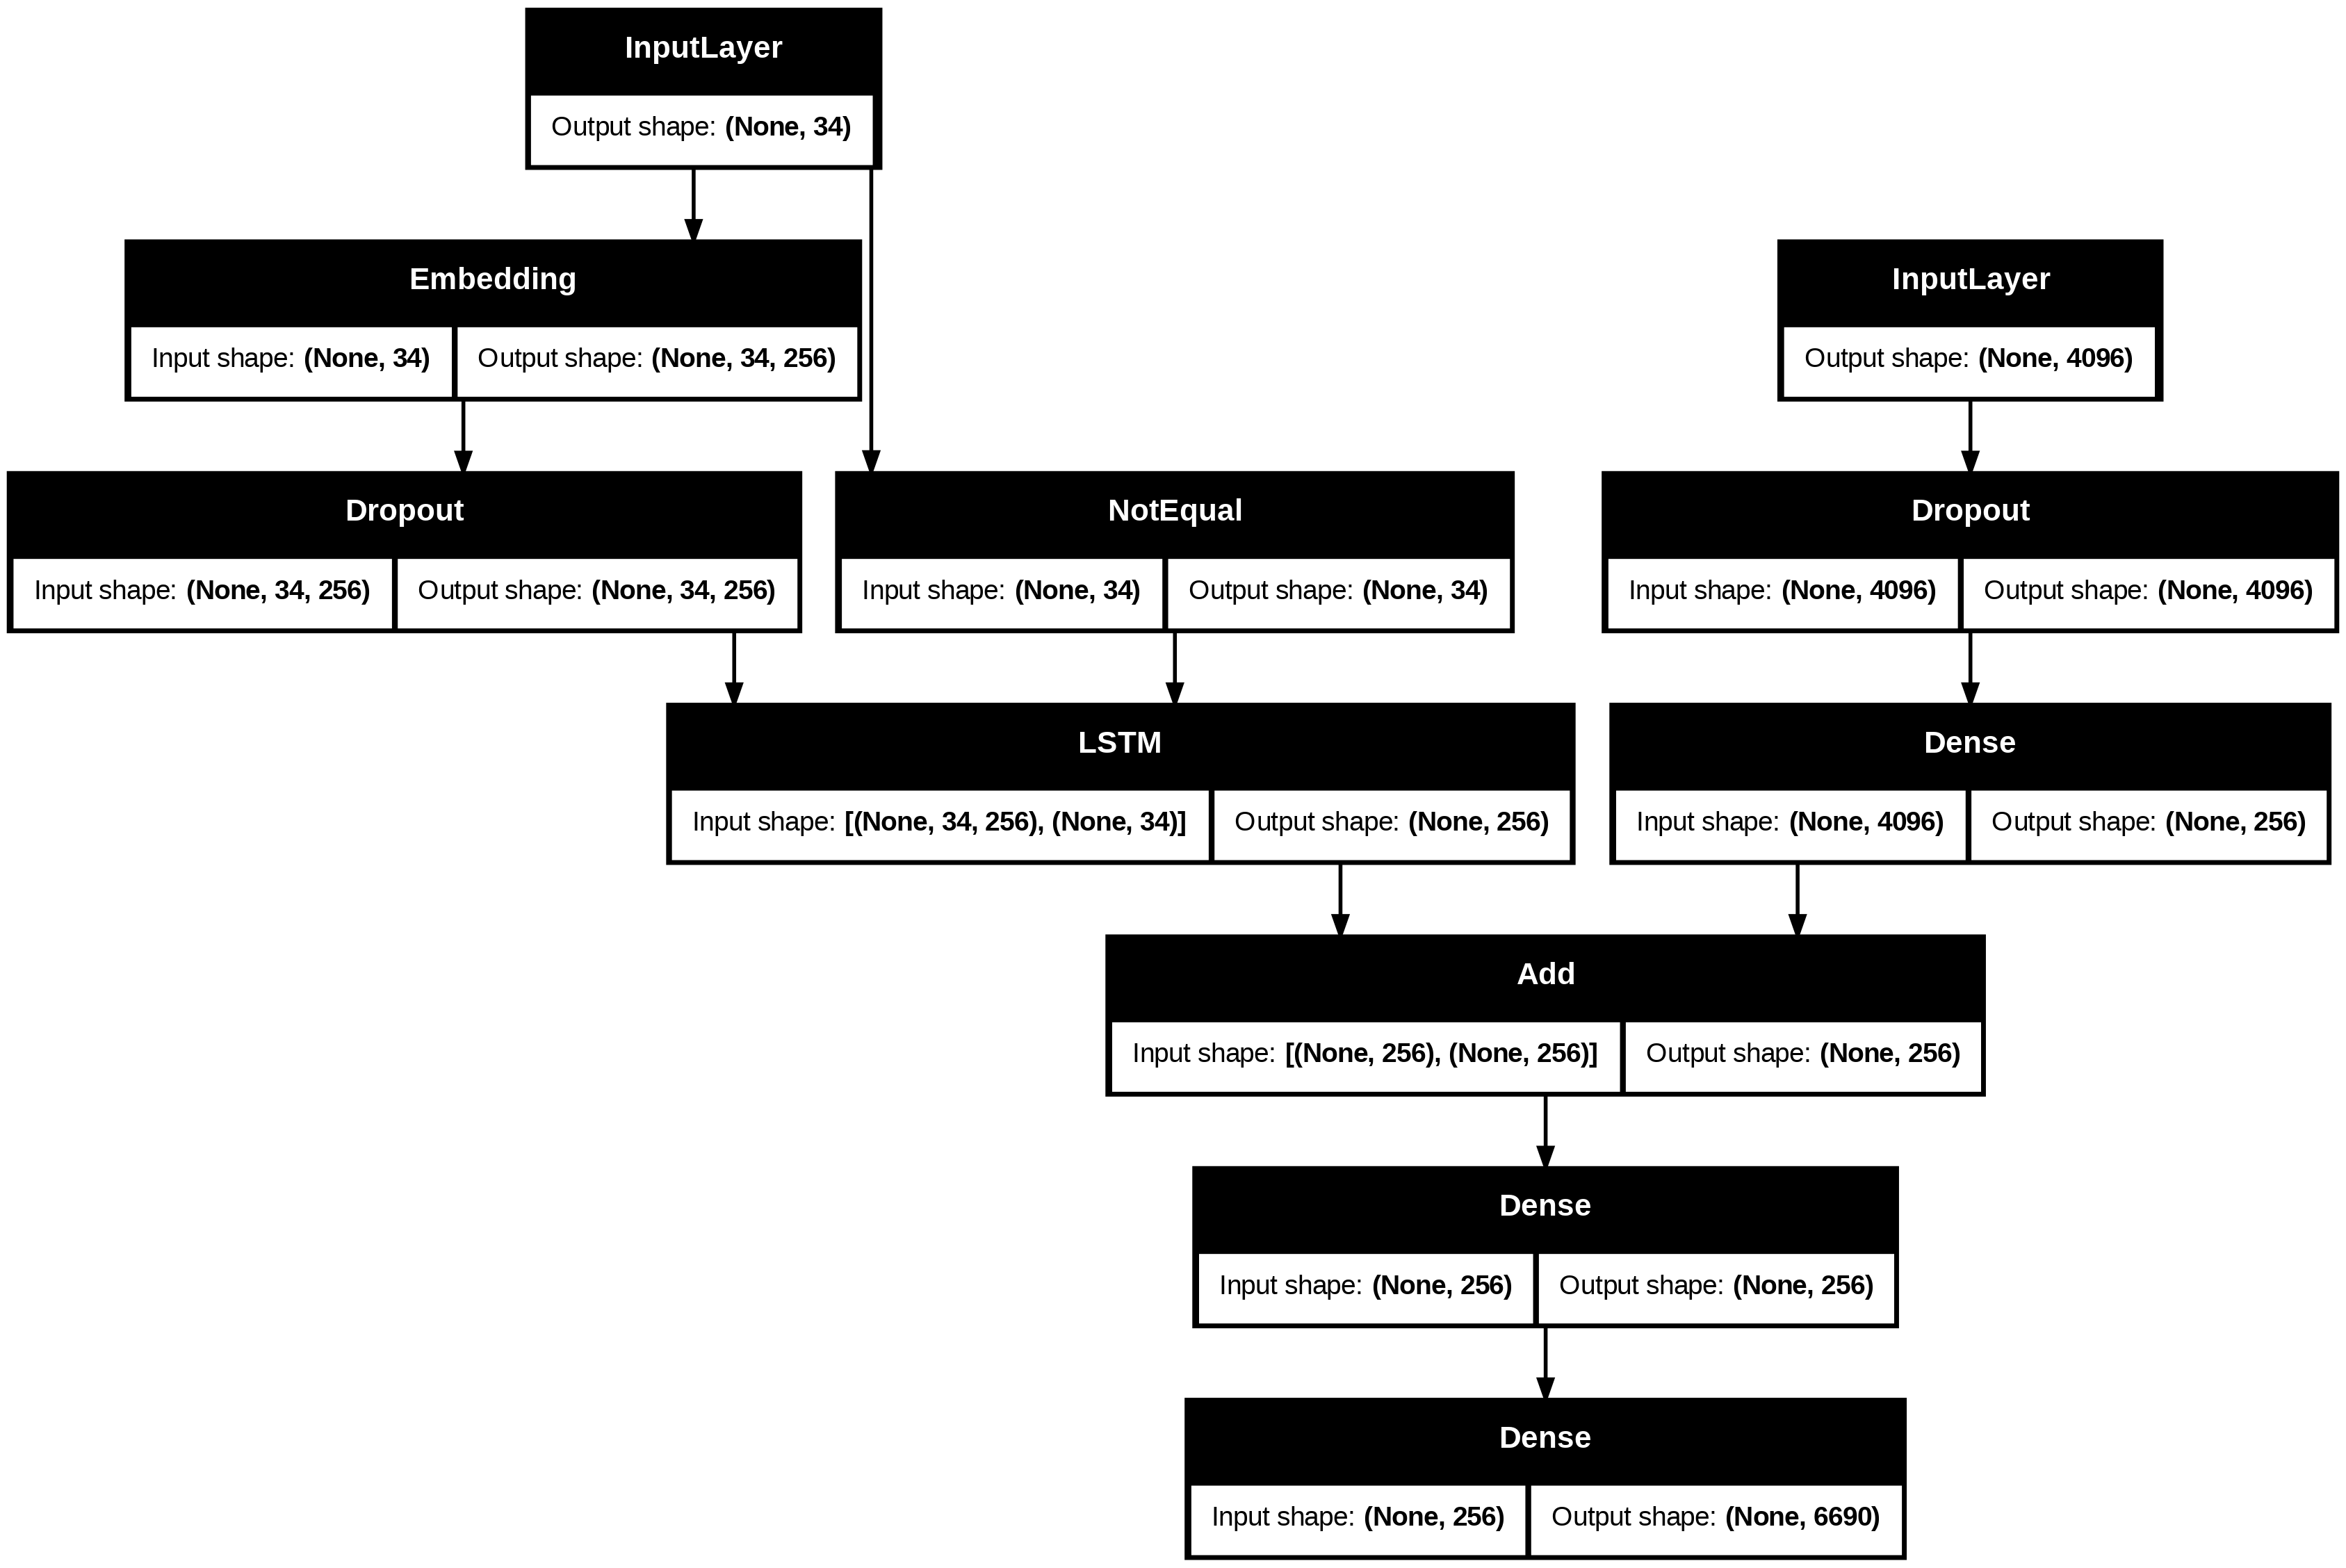

In [33]:
model.compile(loss = 'categorical_crossentropy', optimizer = 'adam')

#plot the model

plot_model(model, show_shapes = True)

In [34]:
# train the model

epochs = 15
batch_size = 64
steps = sum(len(mapping[key]) for key in train) // batch_size
for i in range(epochs):
  # create data generator
  generator = data_generator(train, mapping, features, tokenizer, max_length, vocab_size, batch_size)

  #fit the one epoch
  model.fit(generator, epochs = 1, steps_per_epoch= steps, verbose = 1)


568/568 ━━━━━━━━━━━━━━━━━━━━ 229s 395ms/step - loss: 4.7824
568/568 ━━━━━━━━━━━━━━━━━━━━ 224s 395ms/step - loss: 3.1284
568/568 ━━━━━━━━━━━━━━━━━━━━ 224s 395ms/step - loss: 2.7345
568/568 ━━━━━━━━━━━━━━━━━━━━ 227s 400ms/step - loss: 2.5108
568/568 ━━━━━━━━━━━━━━━━━━━━ 230s 406ms/step - loss: 2.3492
568/568 ━━━━━━━━━━━━━━━━━━━━ 225s 397ms/step - loss: 2.2333
568/568 ━━━━━━━━━━━━━━━━━━━━ 227s 400ms/step - loss: 2.1409
568/568 ━━━━━━━━━━━━━━━━━━━━ 227s 399ms/step - loss: 2.0675
568/568 ━━━━━━━━━━━━━━━━━━━━ 226s 398ms/step - loss: 1.9816
568/568 ━━━━━━━━━━━━━━━━━━━━ 226s 398ms/step - loss: 1.9234
568/568 ━━━━━━━━━━━━━━━━━━━━ 229s 403ms/step - loss: 1.8901
568/568 ━━━━━━━━━━━━━━━━━━━━ 228s 402ms/step - loss: 1.8406
568/568 ━━━━━━━━━━━━━━━━━━━━ 229s 403ms/step - loss: 1.7983
568/568 ━━━━━━━━━━━━━━━━━━━━ 229s 404ms/step - loss: 1.7484
568/568 ━━━━━━━━━━━━━━━━━━━━ 236s 416ms/step - loss: 1.7144


In [35]:
model.save('/content/drive/MyDrive/DL Folder Drive/Image_Caption_Generator_model.h5')

In [36]:
# GENERATE CAPTIONS FOT THE IMAGE

def idx_to_word(integer,tokenizer):
  for word, index in tokenizer.word_index.items():
    if index == integer:
      return word
  return None

In [37]:
# generate caption for an image
def predict_caption(model, image, tokenizer, max_length):
  # add start tag for generation process
  in_text = 'start'
  # iterate over the max length of sequence
  for i in range(max_length):
    # encode input sequence
    sequence = tokenizer.texts_to_sequences([in_text])[0]
    # pad the sequence
    sequence = pad_sequences([sequence], maxlen = max_length, padding='post')
    # predict next word
    yhat = model.predict([image, sequence], verbose = 0)
    # get index with high probability
    yhat = np.argmax(yhat)
    # convert index to word
    word = idx_to_word(yhat, tokenizer)
    # stop if word not found
    if word is None:
      break
    # append word as input for generating next word

    in_text += " " + word
    # stop if we reach end tag
    if word == 'end':
      break
  # remove start/end before returning
  final_caption = in_text.replace('start', '').replace('end', '').strip()
  return final_caption



In [38]:
from nltk.translate.bleu_score import corpus_bleu

# validate with test data
actual, predicted = list(), list()

for key in tqdm(test):
  # get acutal caption
  captions = mapping[key]
  # predict the caption for image
  y_pred = predict_caption(model, features[key], tokenizer, max_length)
  # split into words
  actual_captions = [caption.split() for caption in captions]
  y_pred = y_pred.split()

  # append to the list
  actual.append(actual_captions)
  predicted.append(y_pred)

# calculate BLEU score
print("BLEU-1: %f" % corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0)))
print("BLEU-2: %f" % corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0)))


  0%|          | 0/810 [00:00<?, ?it/s]

BLEU-1: 0.399411
BLEU-2: 0.225585


In [39]:
# VISULIZE THE RESULTS
from PIL import Image
import matplotlib.pyplot as plt
def generate_caption(image_name):

  #load the image
  #image_name = "1305564994_00513f9a5b.jpg"
  image_id = image_name.split('.')[0]
  img_path = os.path.join(image_folder, image_name)
  image = Image.open(img_path)
  captions = mapping[image_id]
  print('---------------------Actual---------------------')
  for caption in captions:
    print(caption)

  #predict the caption
  y_pred = predict_caption(model, features[image_id], tokenizer, max_length)
  print('--------------------Predicted--------------------')
  print(y_pred)
  plt.imshow(image)


---------------------Actual---------------------
start two racer drive white bike down road end
start two motorist be ride along on their vehicle that be oddly design and color end
start two person be in small race car drive by green hill end
start two person in race uniform in street car end
--------------------Predicted--------------------
two person ride on race vehicle in matching position of car


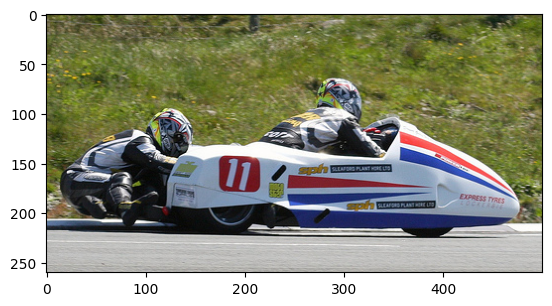

In [40]:
generate_caption('1305564994_00513f9a5b.jpg')

---------------------Actual---------------------
start man in black outfit be ride blue snowmobile across the snow end
start man ride purple snowmobile end
start man wear snow clothes and helmet drive snow vehicle in the snow end
start man with helmet be go snowmobile end
start person ride snowmobile on large amount of snow end
--------------------Predicted--------------------
child in red coat slide down snow tube


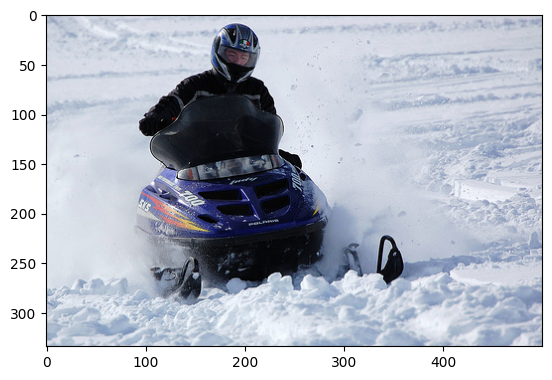

In [41]:
generate_caption('3430287726_94a1825bbf.jpg')

In [42]:
model.save('/content/drive/MyDrive/DL Folder Drive/Final_Image_Caption_Generator_model.h5')

In [43]:
# Save the tokenizer
import pickle
with open('/content/drive/MyDrive/DL Folder Drive/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

In [44]:
# save the maximum caption length
with open('/content/drive/MyDrive/DL Folder Drive/max_length.pkl', 'wb') as f:
    pickle.dump(max_length, f)

In [45]:
with open('/content/drive/MyDrive/DL Folder Drive/features.pkl', 'wb') as f:
    pickle.dump(features, f)